In [ ]:
# pip install some library
%pip install einops matplotlib jupyter_black

In [2]:
%load_ext jupyter_black

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from einops.layers.torch import Rearrange, Reduce

# Data preparation
We first need to prepare the data set: download the data, split train/val set and do normalisation. This part is taken from https://teaching.pages.centralesupelec.fr/deeplearning-lectures-build/00-pytorch-fashionMnist.html

In [2]:
# 1. Get the data
# Change path accordingly
dataset_dir = "~/FashionMNIST"
train_valid_dataset = torchvision.datasets.FashionMNIST(
    root=dataset_dir, train=True, transform=None, download=True
)
train_dataset, valid_dataset = torch.utils.data.dataset.random_split(
    train_valid_dataset, [0.8, 0.2]
)
test_dataset = torchvision.datasets.FashionMNIST(
    root=dataset_dir, transform=None, train=False  # transforms.ToTensor(),
)

In [3]:
# 2. Compute the normalization
class Scaler(torch.nn.Module):
    def __init__(self):
        self.mean_: torch.Tensor | None = None
        self.std_: torch.Tensor | None = None
        self.toTensor = transforms.ToTensor()

    def fit(self, dataset) -> None:
        if self.mean_ is None:
            self.mean_ = torch.zeros_like(self.toTensor(dataset[0][0]))
            self.std_ = torch.zeros_like(self.toTensor(dataset[0][0]))

        # Mean
        for img, _ in dataset:
            self.mean_ += self.toTensor(img)
        self.mean_ /= len(dataset)

        # Std
        for img, _ in dataset:
            self.std_ += (self.mean_ - self.toTensor(img)) ** 2
        self.std_ /= len(dataset)
        self.std_ = torch.sqrt(self.std_)
        self.std_[self.std_ == 0] = 1

    def __call__(self, X: torch.Tensor) -> torch.Tensor:
        assert X.shape[-3:] == self.mean_.shape
        return (X - self.mean_) / self.std_

    def inverse_transform(self, X: torch.Tensor) -> torch.Tensor:
        assert X.shape[-3:] == self.mean_.shape
        return X * self.std_ + self.mean_


scaler = Scaler()
scaler.fit(train_dataset)

In [6]:
from torchvision import transforms

class DatasetTransformer(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.base_dataset[index]
        return self.transform(img), target

    def __len__(self):
        return len(self.base_dataset)

train_data_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.25),
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    scaler,
])

data_transforms = transforms.Compose([
    transforms.ToTensor(),
    scaler,
])

train_dataset = DatasetTransformer(train_dataset, train_data_transforms)
valid_dataset = DatasetTransformer(valid_dataset, data_transforms)
test_dataset = DatasetTransformer(test_dataset, data_transforms)

In [7]:
# 4. Prepare data loader
num_threads = 16  # Loading the dataset is using xxx CPU threads
batch_size = 4096  # Using minibatches of xxx samples

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_threads
)

valid_loader = torch.utils.data.DataLoader(
    dataset=valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_threads
)


test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_threads
)

# Model definition

In [11]:
class Conv2DClassificationModel(nn.Module):
    def __init__(self, n_input: int, n_classes: int):
        super(Conv2DClassificationModel, self).__init__()
        self.n_classes = n_classes

        self.layers = nn.Sequential(
            nn.Conv2d(n_input, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            Rearrange("b c h w -> b (c h w)"),
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Linear(128, n_classes),
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        y = self.layers(X)
        return y

    def predict_proba(self, X: torch.Tensor) -> torch.Tensor:
        y = self.forward(X)
        p = self.softmax(y)
        return p

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        p = self.forward(X)
        c = torch.argmax(p, dim=1)
        return c

In [12]:
n_epochs = 25
learning_rate = 0.01
model = Conv2DClassificationModel(1, 10)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_set_len = len(train_loader)
val_set_len = len(valid_loader)
train_loss, val_loss = [], []

In [13]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
best_loss = 10000000.0
for epoch in range(n_epochs):
    model.train()
    accu = 0.0

    for X_, y_ in train_loader:
        # Move to CPU
        X_, y_ = X_.to(device), y_.to(device)
        # Forward pass
        y_hat = model(X_)
        loss = loss_fn(y_hat, y_)
        accu += loss.to(device).item()

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(accu / train_set_len)

    # Validation - no gradient & eval mode
    model.eval()
    accu = 0.0
    with torch.no_grad():
        for X_, y_ in valid_loader:
            X_, y_ = X_.to(device), y_.to(device)
            # Forward pass
            y_hat = model(X_)
            loss = loss_fn(y_hat, y_)
            accu += loss.item()
        val_loss.append(accu / val_set_len)
        if best_loss > val_loss[-1]:
            best_loss = val_loss[-1]
            torch.save(model.state_dict(), "best_model.pt")
    print(f"Train_loss: {train_loss[-1]} and Val_loss: {val_loss[-1]}")

Train_loss: 1.4474359105030696 and Val_loss: 0.8205353816350301
Train_loss: 0.8036976357301077 and Val_loss: 0.642477293809255
Train_loss: 0.6710734168688456 and Val_loss: 0.5531032880147299
Train_loss: 0.6007499148448309 and Val_loss: 0.49521641929944354
Train_loss: 0.550609161456426 and Val_loss: 0.4609984556833903
Train_loss: 0.5192403097947439 and Val_loss: 0.43779879808425903
Train_loss: 0.490690253674984 and Val_loss: 0.408335675795873
Train_loss: 0.4713780457774798 and Val_loss: 0.41059676806132
Train_loss: 0.4604310616850853 and Val_loss: 0.389983206987381
Train_loss: 0.43992169201374054 and Val_loss: 0.3719378213087718
Train_loss: 0.4445742691556613 and Val_loss: 0.3748359680175781
Train_loss: 0.4299616143107414 and Val_loss: 0.3676997621854146
Train_loss: 0.41809291144212085 and Val_loss: 0.357745627562205
Train_loss: 0.4116925299167633 and Val_loss: 0.34573447704315186
Train_loss: 0.39544906963904697 and Val_loss: 0.3357940415541331
Train_loss: 0.3902462497353554 and Val_los

In [14]:
print(best_loss)

0.3108603060245514


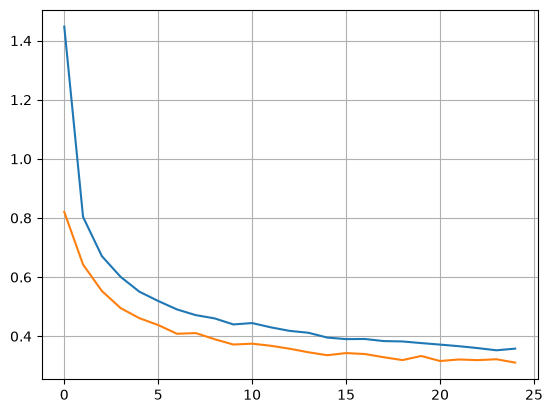

In [15]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.grid()

In [16]:
model.eval()
acc = 0.0
with torch.no_grad():
    for X_, y_ in test_loader:
        X_, y_ = X_.to(device), y_.to(device)
        y_hat = model.predict(X_)
        acc += (y_ == y_hat).sum().item()
    acc /= len(test_dataset)
print(acc * 100)

87.74


In [17]:
model_best = Conv2DClassificationModel(1, 10)
model_best.load_state_dict(torch.load("best_model.pt", weights_only=True))
model_best.to(device)
acc = 0.0
with torch.no_grad():
    for X_, y_ in test_loader:
        X_, y_ = X_.to(device), y_.to(device)
        y_hat = model_best.predict(X_)
        acc += (y_ == y_hat).sum().item()
    acc /= len(test_dataset)
print(acc * 100)

87.74
